In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

raw_csv_2020 = Path("../../data/anes/anes_timeseries_2020_csv_20220210.csv")
raw_csv_2024 = Path("../../data/anes/anes_timeseries_2024_csv_20250430.csv")
clean_csv_path = Path("../../data/anes/policy_clean.csv")

# Missing codes
MISSING = {-9, -8, -7, -6, -5, -4, -3, -2, -1, 99}
MISSING_THERM = {-9, -8, -7, -6, -5, -4, 998, 999}

def get_clean_series(df, col, exclude=MISSING):
    """Utility to extract and clean a column from a specific dataframe."""
    if col in df.columns:
        return df[col].replace(exclude, np.nan)
    return pd.Series(np.nan, index=df.index)

# Build policy columns with succinct names (<= 15 chars), except the three specified to remain as-is
policy = {}
# --- PROCESS 2020 DATA ---
print(f"Loading {raw_csv_2020} ...")
df20 = pd.read_csv(raw_csv_2020)
policy = pd.DataFrame(index=df20.index)

# Keep these names exactly as requested
policy["ideology_7pt"] = get_clean_series(df20, "V201200")
policy["party_id_signed"] = get_clean_series(df20, "V201228").map({1: -1, 2: 1, 3: 0, 5: 0, 0: 0})

# Immigration / rights / institutions
policy["imm_unauth"]   = get_clean_series(df20, "V201417")        
policy["birthright"]   = get_clean_series(df20, "V201420x")
policy["paid_leave"]   = get_clean_series(df20, "V201405x")
policy["trump_corr"]   = get_clean_series(df20, "V201382x")
policy["journ_access"] = get_clean_series(df20, "V201375x")

# Guns / crime / courts
policy["gun_bkg_chk"]  = get_clean_series(df20, "V202341x")
policy["illeg_child"]  = get_clean_series(df20, "V201423x")
policy["death_pen"]    = get_clean_series(df20, "V201345x")
policy["abortion"]     = get_clean_series(df20, "V201336", exclude={-9, -8, 5})
policy["scotus_abort"] = get_clean_series(df20, "V201342x")
policy["ar_ban"]       = get_clean_series(df20, "V202344x")

#  economy
policy["econ_now"]     = get_clean_series(df20, "V201324")
policy["voter_id"]     = get_clean_series(df20, "V201359x")
policy["felon_vote"]   = get_clean_series(df20, "V201362x")



# Health / education / spending
policy["vax_school"]   = get_clean_series(df20, "V202331x")
policy["spend_border"] = get_clean_series(df20, "V201308x")
policy["spend_welfare"]= get_clean_series(df20, "V201314x")        
policy["spend_poor"]   = get_clean_series(df20, "V201320x")
policy["spend_school"] = get_clean_series(df20, "V201305x")
# Governance / social issues
policy["checks_power"] = get_clean_series(df20, "V201367")
policy["border_wall"]  = get_clean_series(df20, "V201426x")
policy["trans_bath"]   = get_clean_series(df20, "V201411x")
policy["trans_military"]   = get_clean_series(df20, "V202390x")

policy["lg_job"]  = get_clean_series(df20, "V201414x")
policy["lg_marry"]  = get_clean_series(df20, "V201414x")
policy["lg_refuse_service"]  = get_clean_series(df20, "V201408x")

policy["police_force"] = get_clean_series(df20, "V202351")

policy["assist_black"] = get_clean_series(df20, "V201258")
policy['black_favor'] = get_clean_series(df20, "V202300") 
policy['diversity'] = get_clean_series(df20, "V202373x")

policy["job_gov_guar"]     = get_clean_series(df20, "V201255")
policy["govt_health"]  = get_clean_series(df20, "V201252")
policy["obamacare"]    = get_clean_series(df20, "V202328x")

# Spending / unrest / climate / foreign
policy["svc_spend"]    = get_clean_series(df20, "V201246")
policy["def_spend"]    = get_clean_series(df20, "V201249")
policy["urban_unrest"] = get_clean_series(df20, "V201429")
policy["clim_imp"]     = get_clean_series(df20, "V202333")
policy["rus_interf"]   = get_clean_series(df20, "V201428")

# Feeling thermometers
policy["ft_trans"]     = get_clean_series(df20, "V202172", exclude=MISSING_THERM)
policy["ft_union"]     = get_clean_series(df20, "V202162", exclude=MISSING_THERM)
policy["ft_fem"]       = get_clean_series(df20, "V202160", exclude=MISSING_THERM)
policy["ft_sci"]       = get_clean_series(df20, "V202173", exclude=MISSING_THERM)
policy["ft_police"]    = get_clean_series(df20, "V202171", exclude=MISSING_THERM)

# Environment / guns / military
policy["env_bus"]      = get_clean_series(df20, "V201262")   
policy["ghg_emiss"]    = get_clean_series(df20, "V202336x")
policy["gun_imp"]      = get_clean_series(df20, "V202338")
policy["mil_force"]    = get_clean_series(df20, "V201350")
policy['millionaire_tax'] = get_clean_series(df20, "V202325")
policy['min_wage'] = get_clean_series(df20, "V202377")

policy['free_trade'] = get_clean_series(df20, "V202361x")
policy['intl_trade_job'] = get_clean_series(df20, "V202367x")


# --- PROCESS 2024 DATA ---
print(f"Loading {raw_csv_2024} ...")
df24 = pd.read_csv(raw_csv_2024)
p24 = pd.DataFrame(index=df24.index)

# 2024 Core IDs
p24["ideology_7pt"] = get_clean_series(df24, "V241177")
# Mapping V241227x (1-3: Dem, 4: Ind, 5-7: Rep) to your -1/1/0 scale
p24["party_id_signed"] = get_clean_series(df24, "V241227x").map({1: -1, 2: -1, 3: -1, 4: 0, 5: 1, 6: 1, 7: 1})

# New 2024 Specific Questions
p24["ft_asian"]      = get_clean_series(df24, "V242514", exclude=MISSING_THERM)
p24["biden_foreign"] = get_clean_series(df24, "V241146x")
p24["limit_imports"] = get_clean_series(df24, "V242226x")
p24["immig_levels"]  = get_clean_series(df24, "V242227")
p24["biden_crime"]   = get_clean_series(df24, "V241155x")
p24["affirm_action"] = get_clean_series(df24, "V242245x")
p24["health_spend"]  = get_clean_series(df24, "V242353x")
p24["dei_college"]   = get_clean_series(df24, "V241290x")
p24["discuss_race"]  = get_clean_series(df24, "V242026")
p24["israel_aid"]    = get_clean_series(df24, "V241403x")
p24["vote_denied"]   = get_clean_series(df24, "V241316")
p24["crime_spend"]   = get_clean_series(df24, "V241270")
p24['biden_economy']    = get_clean_series(df24, "V241143x")   
p24['biden_abortion']    = get_clean_series(df24, "V241149x")   
p24['biden_immigration']    = get_clean_series(df24, "V241152x")


# --- MERGE AND FINALIZE ---
# Add year indicator
policy["survey_year"] = 2020
p24["survey_year"] = 2024


# Assemble clean DataFrame
clean = pd.concat([policy, p24], axis=0, ignore_index=True)
clean["ideology_3pt_signed"] = clean["ideology_7pt"].map({1: 1, 2: 1, 3: 1, 4: 0, 5: -1, 6: -1, 7: -1})
# Diagnostics
missing_in_file = [k for k, s in policy.items() if s.isna().all()]
if missing_in_file:
    print("Warning: missing raw columns for:", missing_in_file)

too_long = [c for c in clean.columns if c not in {"party_id_signed", "ideology_7pt", "ideology_3pt_signed"} and len(c) > 17]
if too_long:
    raise ValueError(f"These column names exceed 15 characters: {too_long}")

non_null_counts = clean.notna().sum().sort_values(ascending=False)
print("Non-null counts per column:\n", non_null_counts)

clean.to_csv(clean_csv_path, index=False)
print(f"Saved cleaned policy dataset to {clean_csv_path}")


Loading ../../data/anes/anes_timeseries_2020_csv_20220210.csv ...


/scratch/local/jobs/44430373/ipykernel_2360634/2420619362.py:23: DtypeWarning: Columns (15,17,18,19,21,22,23,25,26,27,29,30,31,33,34,35,37,38,1508,1509) have mixed types. Specify dtype option on import or set low_memory=False.
  df20 = pd.read_csv(raw_csv_2020)


Loading ../../data/anes/anes_timeseries_2024_csv_20250430.csv ...


/scratch/local/jobs/44430373/ipykernel_2360634/2420619362.py:106: DtypeWarning: Columns (2,3,8,10,11,16,18,19,20,22,23,24,26,27,28,30,31,32,34,35,1284,1285) have mixed types. Specify dtype option on import or set low_memory=False.
  df24 = pd.read_csv(raw_csv_2024)


Non-null counts per column:
 survey_year            13801
party_id_signed        13714
ideology_3pt_signed    11788
ideology_7pt           11788
econ_now                8259
                       ...  
affirm_action           4707
health_spend            4690
ft_asian                4684
limit_imports           4649
discuss_race            1454
Length: 70, dtype: int64
Saved cleaned policy dataset to ../../data/anes/policy_clean.csv


In [2]:
issue_meta = {
    # Ideology / partisanship
    "ideology_7pt": {
        "area": "Ideology",
        "explanation": "Seven-point ideological self-placement on a liberal–conservative scale."
    },
    "ideology_3pt_signed": {
        "area": "Ideology",
        "explanation": "Collapsed ideology measure indicating liberal vs conservative orientation (signed)."
    },
    "party_id_signed": {
        "area": "Partisanship",
        "explanation": "Party identification coded as Democrat (−1), Republican (+1), and non-identifier/other (0)."
    },

    # Immigration
    "imm_unauth": {
        "area": "Immigration",
        "explanation": "Policy preferences regarding unauthorized/undocumented immigrants."
    },
    "birthright": {
        "area": "Immigration",
        "explanation": "Support for birthright citizenship for children born in the U.S. to non-citizen parents."
    },
    "illeg_child": {
        "area": "Immigration",
        "explanation": "Views on how the U.S. should handle children of undocumented immigrants."
    },
    "border_wall": {
        "area": "Immigration",
        "explanation": "Support for constructing a barrier/wall at the U.S.–Mexico border."
    },
    "spend_border": {
        "area": "Immigration",
        "explanation": "Preferences for federal spending levels on border security."
    },
    "immig_levels": {
        "area": "Immigration",
        "explanation": "Opinion on whether the number of immigrants permitted to come to the U.S. should be increased or decreased."
    },
    "biden_immigration": {
        "area": "Immigration",
        "explanation": "Approval of Joe Biden's handling of immigration."
    },

    # Labor / family policy
    "paid_leave": {
        "area": "Labor",
        "explanation": "Support for paid parental/family leave policies for new parents and caregivers."
    },
    "ft_union": {
        "area": "Labor",
        "explanation": "Feeling thermometer rating toward labor unions."
    },
    "min_wage": {
        "area": "Labor",
        "explanation": "Support for raising the minimum wage / minimum-wage policy changes."
    },
    "job_gov_guar": {
        "area": "Labor",
        "explanation": "Support for a government-guaranteed job program (public employment guarantee)."
    },

    # Political institutions / media / accountability
    "checks_power": {
        "area": "Institutions",
        "explanation": "Views on checks and balances and whether branches of government should limit one another's power."
    },
    "journ_access": {
        "area": "Institutions",
        "explanation": "Support for press/journalist access to government officials and government transparency norms."
    },
    "trump_corr": {
        "area": "Institutions",
        "explanation": "Perceptions of corruption involving Donald Trump and/or his administration."
    },
    "rus_interf": {
        "area": "Institutions",
        "explanation": "Concern about Russian interference in U.S. elections and related political influence operations."
    },
    "ft_sci": {
        "area": "Institutions",
        "explanation": "Feeling thermometer rating toward scientists."
    },

    # Elections / democracy
    "voter_id": {
        "area": "Elections",
        "explanation": "Support for voter identification requirements (e.g., photo ID laws)."
    },
    "felon_vote": {
        "area": "Elections",
        "explanation": "Support for restoring or extending voting rights to people with felony convictions."
    },
    "vote_denied": {
        "area": "Elections",
        "explanation": "Perceived frequency of how often people are denied the right to vote."
    },

    # Economy / macro evaluation
    "econ_now": {
        "area": "Economy",
        "explanation": "Evaluation of the current national economy (retrospective economic assessment)."
    },
    "biden_economy": {
        "area": "Economy",
        "explanation": "Approval of Joe Biden's handling of the economy."
    },

    # Guns 
    "gun_bkg_chk": {
        "area": "Guns",
        "explanation": "Support for background checks on gun purchases (including universal background checks)."
    },
    "ar_ban": {
        "area": "Guns",
        "explanation": "Support for banning assault rifles/assault weapons."
    },
    "gun_imp": {
        "area": "Guns",
        "explanation": "Importance placed on gun regulation as a political issue."
    },

    # Crime and Policing (Combined)
    "death_pen": {
        "area": "CrimeAndPolicing",
        "explanation": "Support for the death penalty/capital punishment for serious crimes."
    },
    "police_force": {
        "area": "CrimeAndPolicing",
        "explanation": "Support for police use of force / policing practices."
    },
    "urban_unrest": {
        "area": "CrimeAndPolicing",
        "explanation": "Concern about urban unrest, protests, and disorder."
    },
    "ft_police": {
        "area": "CrimeAndPolicing",
        "explanation": "Feeling thermometer rating toward police."
    },
    "biden_crime": {
        "area": "CrimeAndPolicing",
        "explanation": "Approval of Joe Biden's handling of crime."
    },
    "crime_spend": {
        "area": "CrimeAndPolicing",
        "explanation": "Preference for federal spending levels on dealing with crime."
    },

    # Abortion / courts
    "abortion": {
        "area": "Abortion",
        "explanation": "Attitudes toward abortion legality and access."
    },
    "scotus_abort": {
        "area": "Abortion",
        "explanation": "Views on Supreme Court decisions and judicial intervention related to abortion."
    },
    "biden_abortion": {
        "area": "Abortion",
        "explanation": "Approval of Joe Biden's handling of abortion."
    },

    # Health policy
    "govt_health": {
        "area": "Health",
        "explanation": "Support for government-provided health insurance (e.g., single payer, public provision)."
    },
    "obamacare": {
        "area": "Health",
        "explanation": "Attitudes toward the Affordable Care Act (ACA/'Obamacare')."
    },
    "vax_school": {
        "area": "Health",
        "explanation": "Support for school vaccination requirements for children attending school."
    },
    "health_spend": {
        "area": "Health",
        "explanation": "Preference for government spending to help people pay for health insurance."
    },

    # Spending / welfare / redistribution
    "spend_welfare": {
        "area": "Redistribution",
        "explanation": "Preferences for federal spending on welfare programs / public assistance."
    },
    "spend_poor": {
        "area": "Redistribution",
        "explanation": "Preferences for federal spending to aid the poor / anti-poverty programs."
    },
    "svc_spend": {
        "area": "Redistribution",
        "explanation": "Preferences for government spending on services (general service provision)."
    },
    "millionaire_tax": {
        "area": "Redistribution",
        "explanation": "Support for taxes targeting millionaires."
    },

    # Education
    "spend_school": {
        "area": "Education",
        "explanation": "Preferences for federal spending on public schools and K–12 education."
    },
    "dei_college": {
        "area": "Education",
        "explanation": "Views on Diversity, Equity, and Inclusion (DEI) policies on college campuses."
    },
    "affirm_action": {
        "area": "Education",
        "explanation": "Favor or oppose affirmative action in university admissions."
    },

    # Climate / environment / regulation
    "clim_imp": {
        "area": "Climate",
        "explanation": "Importance assigned to climate change as an issue."
    },
    "ghg_emiss": {
        "area": "Climate",
        "explanation": "Support for regulating greenhouse gas emissions / carbon emissions."
    },
    "env_bus": {
        "area": "Climate",
        "explanation": "Tradeoff between environmental protection and business regulation/deregulation."
    },

    # Defense and Foreign Policy
    "def_spend": {
        "area": "ForeignPolicy",
        "explanation": "Preferences for government spending on national defense and the military."
    },
    "mil_force": {
        "area": "ForeignPolicy",
        "explanation": "Support for the use of U.S. military force internationally."
    },
    "biden_foreign": {
        "area": "ForeignPolicy",
        "explanation": "Approval of Joe Biden's handling of foreign relations."
    },
    "israel_aid": {
        "area": "ForeignPolicy",
        "explanation": "Favor or oppose the U.S. providing military assistance to Israel."
    },

    # Trade
    "free_trade": {
        "area": "Trade",
        "explanation": "Support for free trade policies and reducing trade barriers."
    },
    "intl_trade_job": {
        "area": "Trade",
        "explanation": "Beliefs about international trade's impact on jobs (job creation/loss from trade)."
    },
    "limit_imports": {
        "area": "Trade",
        "explanation": "Support for placing new limits on imports from other countries."
    },

    # Diversity (Reorganized from Race)
    "assist_black": {
        "area": "Diversity",
        "explanation": "Support for government assistance to Black Americans / addressing racial inequality."
    },
    "black_favor": {
        "area": "Diversity",
        "explanation": "Attitudes toward whether Black people should receive favoritism in society/politics."
    },
    "diversity": {
        "area": "Diversity",
        "explanation": "Attitudes toward diversity initiatives and/or the importance of diversity."
    },
    "ft_asian": {
        "area": "Diversity",
        "explanation": "Feeling thermometer rating toward Asian-Americans."
    },
    "discuss_race": {
        "area": "Diversity",
        "explanation": "Frequency of discussing race or racial issues with children."
    },

    # Transgender (Split Category)
    "trans_bath": {
        "area": "Transgender",
        "explanation": "Views on transgender bathroom access policies."
    },
    "trans_military": {
        "area": "Transgender",
        "explanation": "Views on transgender people serving in the U.S. military."
    },
    "ft_trans": {
        "area": "Transgender",
        "explanation": "Feeling thermometer rating toward transgender people."
    },

    # Lesbian/Gay (Split Category)
    "lg_job": {
        "area": "Lesbian/Gay",
        "explanation": "Views on legal protections against job discrimination for gay/lesbian people."
    },
    "lg_marry": {
        "area": "Lesbian/Gay",
        "explanation": "Support for same-sex marriage / marriage rights for gay and lesbian couples."
    },
    "lg_refuse_service": {
        "area": "Lesbian/Gay",
        "explanation": "Views on refusing service to same-sex couples."
    },

    # Gender (Other)
    "ft_fem": {
        "area": "Gender",
        "explanation": "Feeling thermometer rating toward feminists."
    },
}

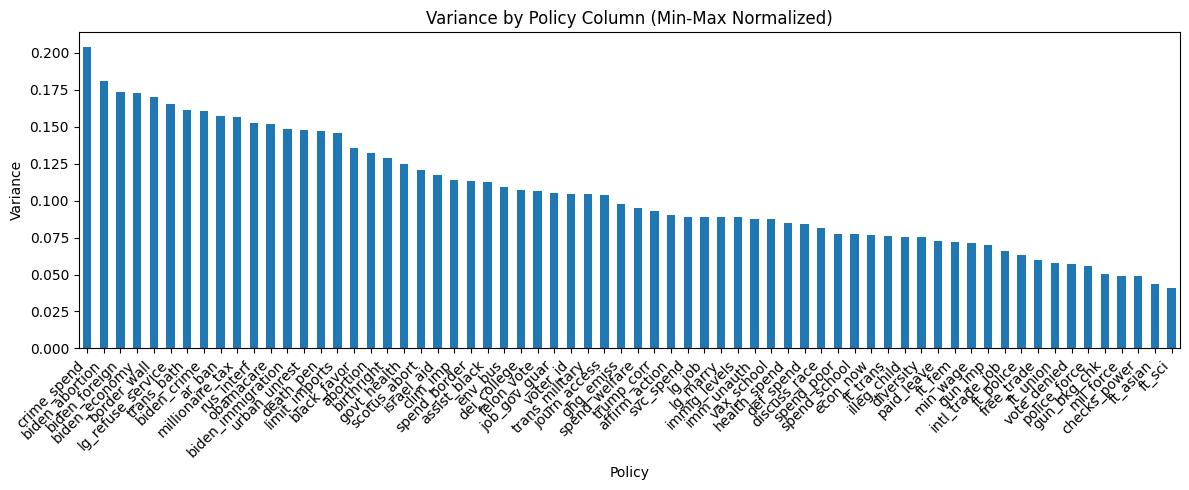

In [3]:
import matplotlib.pyplot as plt

# Load cleaned policy data
clean = pd.read_csv("../../data/anes/policy_clean.csv")

# Define columns to exclude from normalization (ideology and partisanship)
exclude_cols = ['party_id_signed', 'ideology_7pt', 'ideology_3pt_signed', 'survey_year']

# Get policy columns (exclude ideology/partisan columns)
policy_cols = [col for col in clean.columns if col not in exclude_cols]

# Min-max normalize policy columns only
col_min = clean[policy_cols].min(skipna=True)
col_max = clean[policy_cols].max(skipna=True)
col_range = col_max - col_min
safe_range = col_range.replace(0, np.nan)

clean_normalized = clean.copy()
clean_normalized[policy_cols] = (clean[policy_cols] - col_min) / safe_range

# Calculate variance for each policy
variance = {col: clean_normalized[col].var(skipna=True) for col in policy_cols}
variance_sorted = dict(sorted(variance.items(), key=lambda x: x[1], reverse=True))

# Plot 1: Variance
plt.figure(figsize=(12, 5))
pd.Series(variance_sorted).plot(kind='bar')
plt.title('Variance by Policy Column (Min-Max Normalized)')
plt.ylabel('Variance')
plt.xlabel('Policy')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

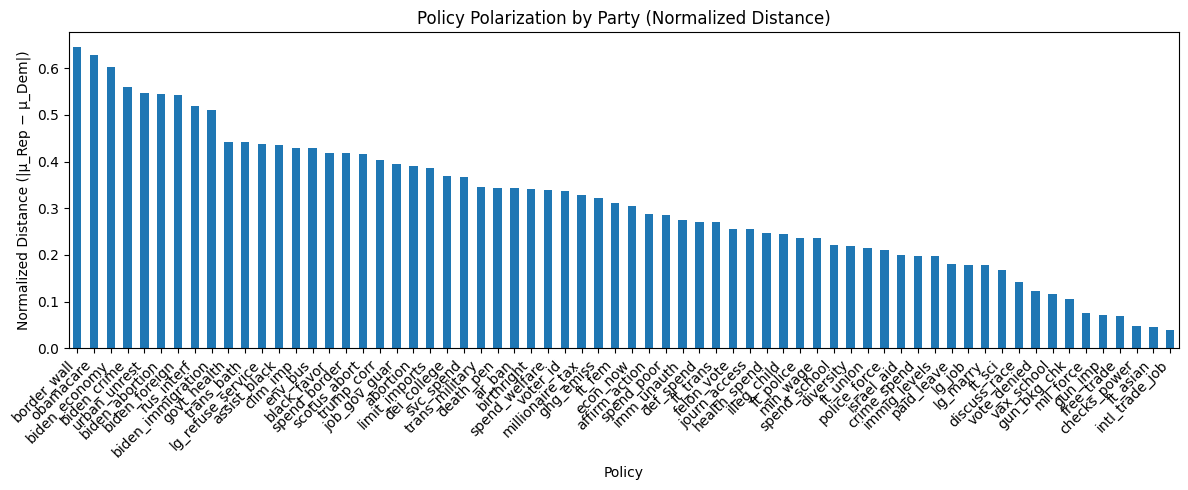


Top 10 Most Polarized Policies (Normalized Distance):
1. border_wall: 0.6443
2. obamacare: 0.6289
3. biden_economy: 0.6020
4. biden_crime: 0.5586
5. urban_unrest: 0.5472
6. biden_abortion: 0.5446
7. biden_foreign: 0.5421
8. rus_interf: 0.5183
9. biden_immigration: 0.5112
10. govt_health: 0.4424


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Calculate polarization by party for each policy (using normalized distance)
polarization = {}

for col in policy_cols:
    # Get data for each party (drop NaNs to ensure valid calculation)
    dem_data = clean_normalized[col][clean['party_id_signed'] == -1].dropna()
    rep_data = clean_normalized[col][clean['party_id_signed'] == 1].dropna()
    
    # We need at least 2 points to calculate mean
    if len(dem_data) < 2 or len(rep_data) < 2:
        polarization[col] = 0.0
        continue
    
    # Calculate Means
    mu_d = dem_data.mean()
    mu_r = rep_data.mean()
    
    # Calculate normalized distance (simple absolute difference of means)
    # Since data is already min-max normalized to [0,1], this gives a [0,1] distance
    polarization[col] = abs(mu_r - mu_d)

# Sort polarization for plotting
polarization_sorted = dict(sorted(polarization.items(), key=lambda x: x[1], reverse=True))

# Plot 2: Polarization
plt.figure(figsize=(12, 5))
pd.Series(polarization_sorted).plot(kind='bar')
plt.title('Policy Polarization by Party (Normalized Distance)')
plt.ylabel('Normalized Distance (|μ_Rep − μ_Dem|)')
plt.xlabel('Policy')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nTop 10 Most Polarized Policies (Normalized Distance):")
for i, (policy, value) in enumerate(list(polarization_sorted.items())[:10], 1):
    print(f"{i}. {policy}: {value:.4f}")

In [5]:
# save polarization and variance as csv
df_results = pd.DataFrame({
    'normalized_distance': pd.Series(polarization),
    'variance': pd.Series(variance)
}).reset_index().rename(columns={"index": "issue"})
df_meta = (
    pd.DataFrame.from_dict(issue_meta, orient="index")
      .reset_index()
      .rename(columns={"index": "issue"})
)
df_out = df_results.merge(df_meta, on="issue", how="left")
missing = df_out[df_out["area"].isna()]["issue"].tolist()
print(f"missing metadata for issues: {missing}")
df_out.to_csv("policy_polarization.csv", index=False)

missing metadata for issues: []


In [6]:
polarization

{'imm_unauth': np.float64(1.0078851129473259),
 'birthright': np.float64(1.0363106760926486),
 'paid_leave': np.float64(0.7138892219014817),
 'trump_corr': np.float64(1.637287924678687),
 'journ_access': np.float64(0.8341543668842112),
 'gun_bkg_chk': np.float64(0.4973398678854416),
 'illeg_child': np.float64(0.9481337519435443),
 'death_pen': np.float64(0.9994836145770344),
 'abortion': np.float64(1.2325316489471152),
 'scotus_abort': np.float64(1.4133026818161256),
 'ar_ban': np.float64(0.9409382852663171),
 'econ_now': np.float64(1.2732922811295637),
 'voter_id': np.float64(1.1909847000895442),
 'felon_vote': np.float64(0.8203449055257549),
 'vax_school': np.float64(0.4048825041927173),
 'spend_border': np.float64(1.5507668598948603),
 'spend_welfare': np.float64(1.2748138341444155),
 'spend_poor': np.float64(1.1768506328594828),
 'spend_school': np.float64(0.8810586440416092),
 'checks_power': np.float64(0.22612411791313203),
 'border_wall': np.float64(2.303003991399405),
 'trans_b

Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


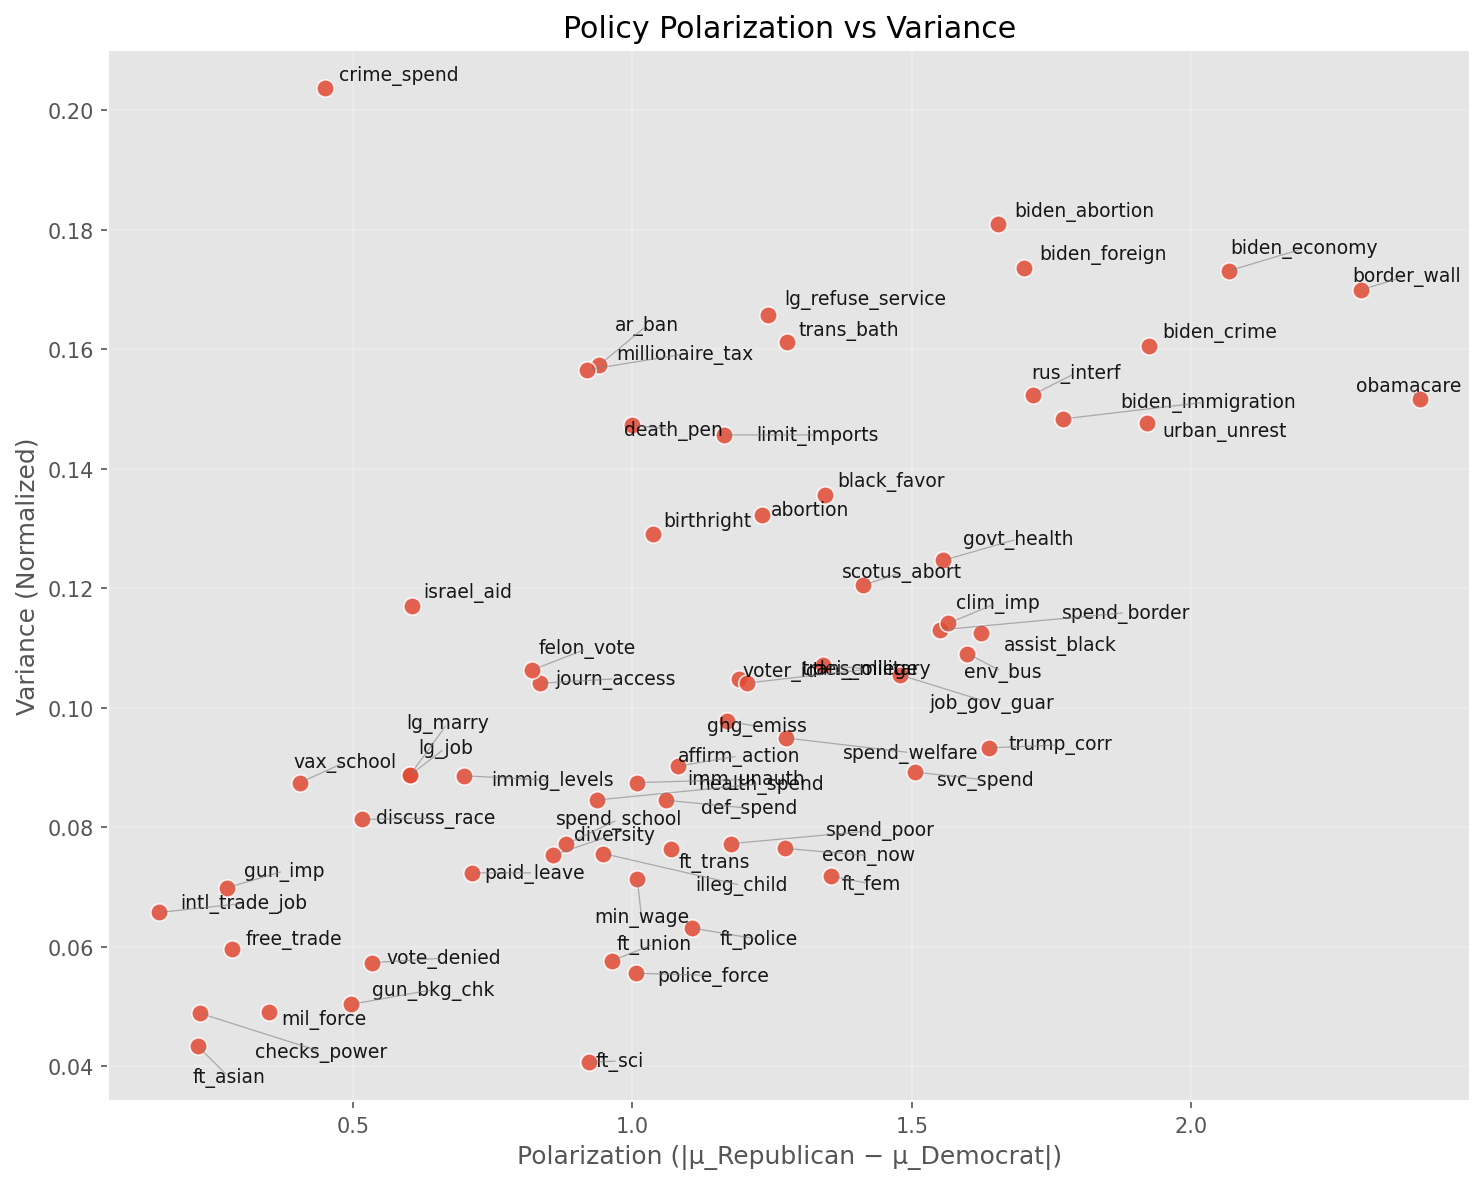

In [7]:
import matplotlib.pyplot as plt
from adjustText import adjust_text

plt.style.use("ggplot")

fig, ax = plt.subplots(figsize=(10, 8), dpi=150)

# Extract x and y values
x_values = [polarization[p] for p in policy_cols]
y_values = [variance[p] for p in policy_cols]

# Scatter plot
ax.scatter(
    x_values,
    y_values,
    s=70,
    alpha=0.85,
    edgecolor="white",
    linewidth=0.8,
)

# Create text objects (start exactly at the point)
texts = []
for p, x, y in zip(policy_cols, x_values, y_values):
    texts.append(
        ax.text(
            x,
            y,
            p,
            fontsize=9,
            alpha=0.9,
        )
    )

ax.set_xlabel("Polarization (|μ_Republican − μ_Democrat|)")
ax.set_ylabel("Variance (Normalized)")
ax.set_title("Policy Polarization vs Variance")
ax.grid(True, alpha=0.25)

# Add modest padding
x_pad = 0.04 * (max(x_values) - min(x_values) or 1)
y_pad = 0.04 * (max(y_values) - min(y_values) or 1)
ax.set_xlim(min(x_values) - x_pad, max(x_values) + x_pad)
ax.set_ylim(min(y_values) - y_pad, max(y_values) + y_pad)

# Strongly constrained adjustment
adjust_text(
    texts,
    x=x_values,
    y=y_values,
    ax=ax,

    # Keep labels close
    expand_points=(1.05, 1.1),
    expand_text=(1.05, 1.1),

    # Weak repulsion forces
    force_points=(0.03, 0.1),
    force_text=(0.03, 0.1),

    # Explicit attraction back to the point
    pull_points=(0.6, 0.6),
    pull_text=(0.6, 0.6),

    # Limit iterations to prevent drift
    lim=100,

    arrowprops=dict(
        arrowstyle="-",
        color="grey",
        lw=0.6,
        alpha=0.6,
    ),
)

fig.tight_layout()
plt.show()
